<a href="https://colab.research.google.com/github/YASHI-11/CLI-Python-Games/blob/main/AIMLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, os, warnings
warnings.filterwarnings("ignore")
print("Python", sys.version)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")


Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [ ]:
FILE_ID = "1cJzGvS7Ht0UyqKjnVMnfjP2Tb7oCfPTy"
URL = f"https://drive.google.com/uc?id={FILE_ID}"

!wget -O mobile_price.csv "{URL}"

import pandas as pd
df = pd.read_csv("mobile_price.csv")
print("Dataset loaded successfully from public Drive link!")
df.head()


--2025-09-06 15:12:07--  https://drive.google.com/uc?id=1cJzGvS7Ht0UyqKjnVMnfjP2Tb7oCfPTy
Resolving drive.google.com (drive.google.com)... 108.177.127.100, 108.177.127.113, 108.177.127.139, ...
Connecting to drive.google.com (drive.google.com)|108.177.127.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cJzGvS7Ht0UyqKjnVMnfjP2Tb7oCfPTy [following]
--2025-09-06 15:12:07--  https://drive.usercontent.google.com/download?id=1cJzGvS7Ht0UyqKjnVMnfjP2Tb7oCfPTy
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.153.132, 2a00:1450:4013:c16::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.153.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122403 (120K) [application/octet-stream]
Saving to: ‘mobile_price.csv’

mobile_price.csv    100%[===================>] 119.53K  --.-KB/s    in 0.001s  

2025-09-06 15:12:08 (112

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
print("Columns:", list(df.columns))
print("\nTarget value counts (if present):")
if 'price_range' in df.columns:
    print(df['price_range'].value_counts())
else:
    print("No 'price_range' column found. Set target accordingly.")

# price_range: 0 (low), 1 (medium), 2 (high), 3 (very high)


Columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

Target value counts (if present):
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0



Missing values per column:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Numeric columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h']


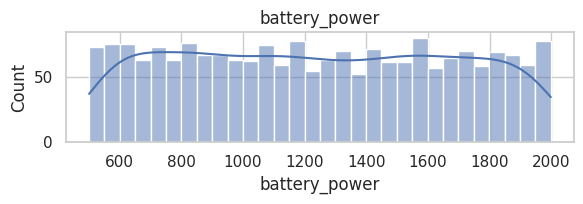

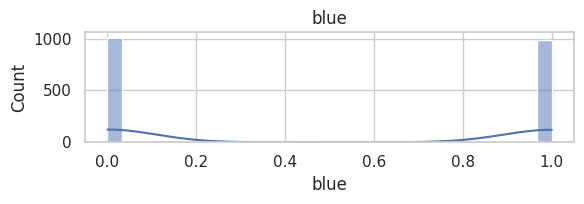

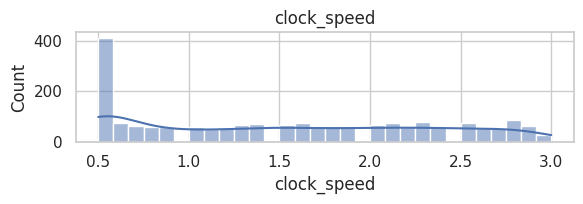

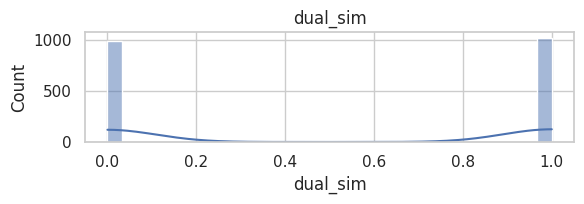

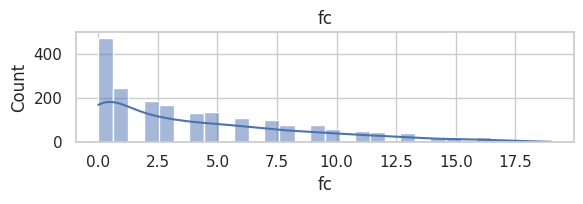

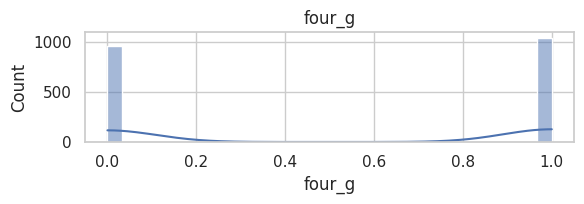

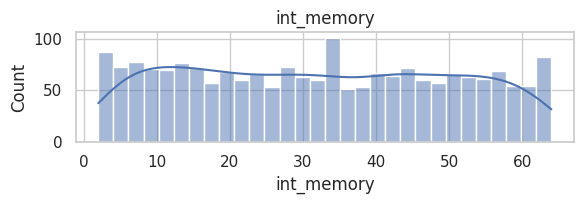

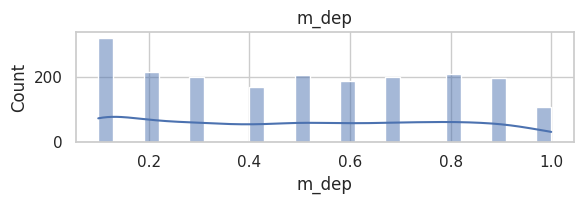

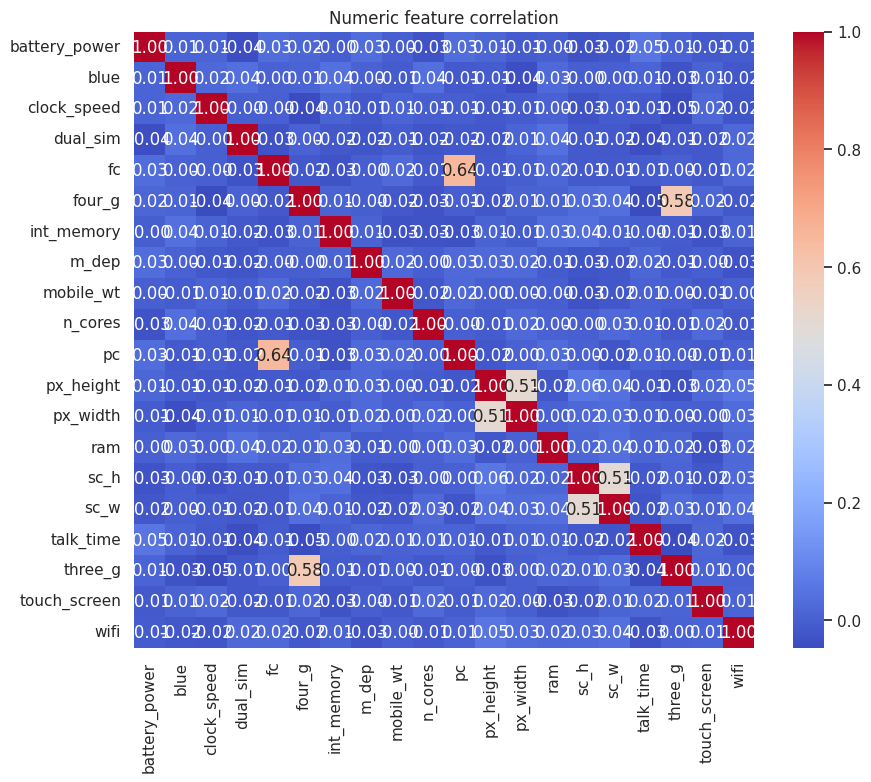

In [ ]:
display(df.describe(include='all').transpose())

print("\nMissing values per column:\n", df.isna().sum())

num_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'price_range' in num_cols: num_cols.remove('price_range')
print("\nNumeric columns:", num_cols[:15])

for col in num_cols[:8]:
    plt.figure(figsize=(6,2.2))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.tight_layout()
    plt.show()

if len(num_cols) > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Numeric feature correlation")
    plt.show()


In [ ]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

if 'price_range' in num_cols:
    num_cols.remove('price_range')

from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

if len(num_cols)>0:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
if len(cat_cols)>0:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing values after imputation:\n", df.isna().sum())


Duplicates: 0
Missing values after imputation:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [ ]:
if 'px_width' in df.columns and 'px_height' in df.columns:
    df['pixel_count'] = df['px_width'] * df['px_height']
    df['pixel_density_ratio'] = df['pixel_count'] / (df['sc_w'].replace(0, np.nan)*df['sc_h'].replace(0, np.nan))
    df['pixel_density_ratio'] = df['pixel_density_ratio'].fillna(df['pixel_density_ratio'].median())

if 'ram' in df.columns:
    df['ram_kb'] = df['ram']
    df['ram_bucket'] = pd.cut(df['ram'], bins=[0,1024,2048,4096,8192,20000], labels=False)

display(df.head().T)


,0,1,2,3,4
battery_power,842.0,1.021000e+03,563.0,615.0,1821.0
blue,0.0,1.000000e+00,1.0,1.0,1.0
clock_speed,2.2,5.000000e-01,0.5,2.5,1.2
dual_sim,0.0,1.000000e+00,1.0,0.0,0.0
fc,1.0,0.000000e+00,2.0,0.0,13.0
four_g,0.0,1.000000e+00,1.0,0.0,1.0
int_memory,7.0,5.300000e+01,41.0,10.0,44.0
m_dep,0.6,7.000000e-01,0.9,0.8,0.6
mobile_wt,188.0,1.360000e+02,145.0,131.0,141.0
n_cores,2.0,3.000000e+00,5.0,6.0,2.0


In [ ]:
target = "price_range"
assert target in df.columns, "Target 'price_range' not found in dataset"

drop_cols = []
for c in ['id','Id','serial','index']:
    if c in df.columns: drop_cols.append(c)

features = [c for c in df.columns if c not in drop_cols + [target]]
X = df[features].copy()
y = df[target].astype(int).copy()

print("Number of features:", len(features))
print("X shape:", X.shape, "y shape:", y.shape)


Number of features: 24
X shape: (2000, 24) y shape: (2000,)


In [ ]:
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')

X_p = preprocessor.fit_transform(X)
print("Transformed X shape:", X_p.shape)


Transformed X shape: (2000, 24)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)
print(X_train.shape, X_test.shape)


(1600, 24) (400, 24)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

from sklearn.pipeline import make_pipeline
results = {}
for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    results[name] = score
    print(f"{name} accuracy: {score:.4f}")

import pandas as pd
pd.Series(results).sort_values(ascending=False)


LogisticRegression accuracy: 0.9725
DecisionTree accuracy: 0.8650
RandomForest accuracy: 0.9075
GradientBoosting accuracy: 0.9300


,0
LogisticRegression,0.9725
GradientBoosting,0.9300
RandomForest,0.9075
DecisionTree,0.8650


Best baseline model: LogisticRegression
Accuracy: 0.9725
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.98      0.95      0.96       100
           2       0.96      0.96      0.96       100
           3       0.97      0.99      0.98       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



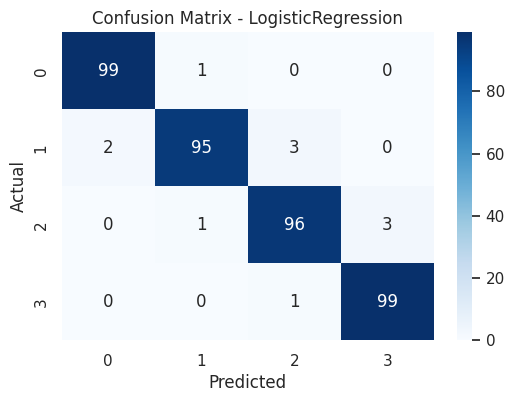

In [ ]:
best_name = max(results, key=results.get)
print("Best baseline model:", best_name)

best_pipe = make_pipeline(preprocessor, models[best_name])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


In [ ]:
def get_feature_names(preprocessor):
    num_feats = num_features
    cat_features_names = []
    if len(cat_features) > 0:
        ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
        try:
            cat_names = ohe.get_feature_names_out(cat_features).tolist()
        except Exception:
            cat_names = []
            for i, c in enumerate(cat_features):
                cat_names += [f"{c}_{val}" for val in range(ohe.categories_[i].shape[0])]
        cat_features_names = cat_names
    return num_feats + cat_features_names

preprocessor_full = preprocessor
preprocessor_full.fit(X)
feature_names = get_feature_names(preprocessor_full)
len(feature_names), feature_names[:20]


(24,
 ['battery_power',
  'blue',
  'clock_speed',
  'dual_sim',
  'fc',
  'four_g',
  'int_memory',
  'm_dep',
  'mobile_wt',
  'n_cores',
  'pc',
  'px_height',
  'px_width',
  'ram',
  'sc_h',
  'sc_w',
  'talk_time',
  'three_g',
  'touch_screen',
  'wifi'])

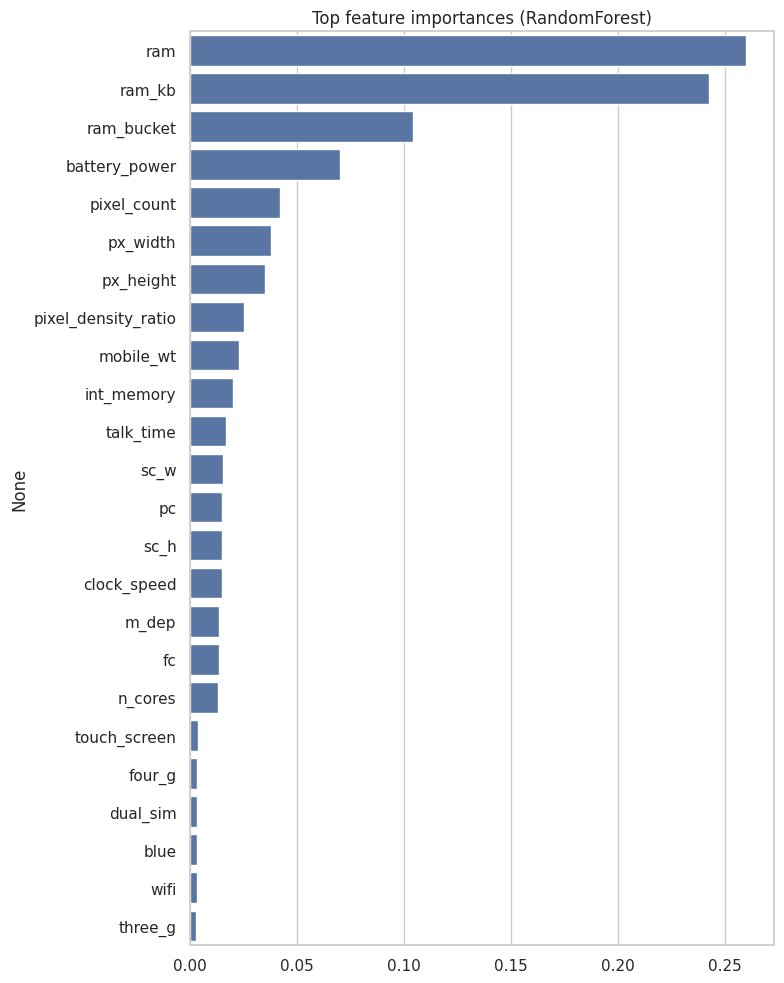

,0
ram,0.260011
ram_kb,0.242821
ram_bucket,0.104255
battery_power,0.070251
pixel_count,0.042201
px_width,0.037767
px_height,0.035371
pixel_density_ratio,0.025529
mobile_wt,0.022986
int_memory,0.020055


In [ ]:
final_est = best_pipe.named_steps[best_pipe.steps[-1][0]] if hasattr(best_pipe, 'steps') else None
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=400, random_state=42)
from sklearn.pipeline import Pipeline
full_pipe = Pipeline([('prep', preprocessor_full), ('rf', rf)])
full_pipe.fit(X_train, y_train)

importances = full_pipe.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(30)
plt.figure(figsize=(8,10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top feature importances (RandomForest)")
plt.tight_layout()
plt.show()

display(feat_imp)


In [ ]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([('prep', preprocessor), ('rf', RandomForestClassifier(random_state=42))])
param_grid = {
    'rf__n_estimators': [200, 400],
    'rf__max_depth': [None, 12, 20],
    'rf__min_samples_split': [2, 5]
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_grid = grid.best_estimator_

y_pred_grid = best_grid.predict(X_test)
from sklearn.metrics import accuracy_score
print("Test accuracy (tuned RF):", accuracy_score(y_test, y_pred_grid))
print("Classification report (tuned RF):\n", classification_report(y_test, y_pred_grid))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'rf__max_depth': 12, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV score: 0.8687510686688543
Test accuracy (tuned RF): 0.8975
Classification report (tuned RF):
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.88      0.84      0.86       100
           2       0.82      0.86      0.84       100
           3       0.94      0.92      0.93       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



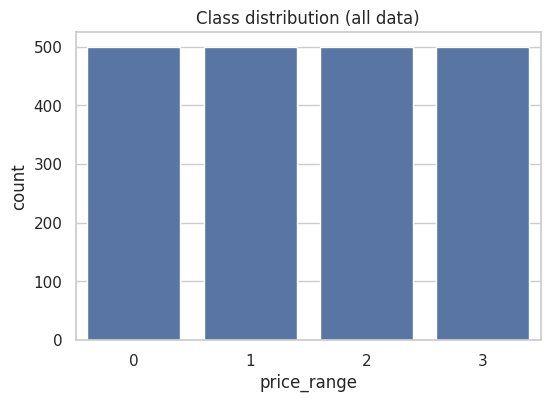

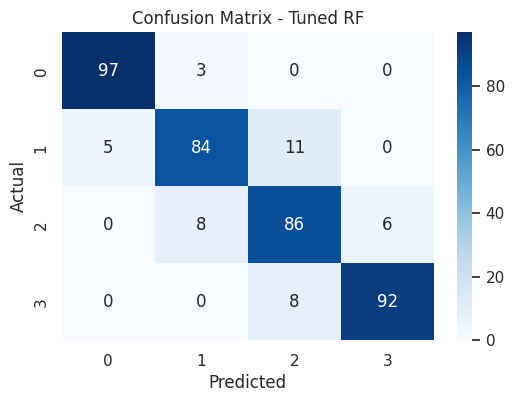

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class distribution (all data)")
plt.show()

cm = confusion_matrix(y_test, y_pred_grid)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned RF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import joblib
model_out = best_grid if 'best_grid' in globals() else best_pipe
joblib.dump(model_out, "mobile_price_classifier_pipeline.pkl")
print("Saved pipeline to mobile_price_classifier_pipeline.pkl")

df.to_csv("cleaned_mobile_data_for_report.csv", index=False)
print("Saved cleaned input as cleaned_mobile_data_for_report.csv")


Saved pipeline to mobile_price_classifier_pipeline.pkl
Saved cleaned input as cleaned_mobile_data_for_report.csv


In [ ]:
print("""

1. Top influencing features (from feature importance): {}
   - Focus marketing and premium pricing on features like RAM, battery_power, primary camera (Pc), pixel resolution, and processor cores.

2. Model performance:
   - Baseline accuracy (best baseline): {:.3f}
   - Tuned RandomForest test accuracy: {:.3f}

""".format(list(feat_imp.index[:6]), results[best_name], accuracy_score(y_test, y_pred_grid)))




1. Top influencing features (from feature importance): ['ram', 'ram_kb', 'ram_bucket', 'battery_power', 'pixel_count', 'px_width']
   - Focus marketing and premium pricing on features like RAM, battery_power, primary camera (Pc), pixel resolution, and processor cores.

2. Model performance:
   - Baseline accuracy (best baseline): 0.973
   - Tuned RandomForest test accuracy: 0.897

3. Business actions:
   - For premium segment: emphasis on high RAM, strong processor, high primary camera MP, large battery.
   - For budget models: maximize value in battery and efficient cameras.

4. Further improvements:
   - Collect more labeled data for rare configurations.
   - Use ensemble stacking and stratified cross-validation.
   - Try feature interactions and non-linear embeddings (e.g., tree-based SHAP for interpretability).

Deliverables:
 - Notebook (.ipynb) with full pipeline
 - cleaned_mobile_data_for_report.csv
 - mobile_price_classifier_pipeline.pkl (saved pipeline)
 - PPT/Report summari